In [1]:
from datasets import load_dataset

dataset = load_dataset("cifar10")

labels = dataset["train"].features["label"].names

label2id = {label: str(i) for i, label in enumerate(labels)}
id2label = {str(i): label for i, label in enumerate(labels)}

print(f"새로운 클래스 10종류: {labels}")

새로운 클래스 10종류: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


In [2]:
from transformers import AutoImageProcessor, AutoModelForImageClassification
from torchvision.transforms import RandomResizedCrop, Resize, CenterCrop, Compose, Normalize, ToTensor

model_checkpoint = "microsoft/resnet-50"
image_processor = AutoImageProcessor.from_pretrained(model_checkpoint)
normalize = Normalize(mean=image_processor.image_mean, std=image_processor.image_std)

if "shortest_edge" in image_processor.size:
    edge = image_processor.size["shortest_edge"]
    size = (edge, edge) 
else:
    size = (image_processor.size["height"], image_processor.size["width"]) 

print(f"적용될 이미지 크기: {size}")

train_transforms = Compose([RandomResizedCrop(size), ToTensor(), normalize])
val_transforms = Compose([Resize(size), CenterCrop(size), ToTensor(), normalize])

def preprocess_train(example_batch):
    example_batch["pixel_values"] = [train_transforms(image.convert("RGB")) for image in example_batch["img"]] 
    return example_batch

def preprocess_val(example_batch):
    example_batch["pixel_values"] = [val_transforms(image.convert("RGB")) for image in example_batch["img"]]
    return example_batch

train_ds = dataset['train'].with_transform(preprocess_train)
test_ds = dataset['test'].with_transform(preprocess_val)

model = AutoModelForImageClassification.from_pretrained(
    model_checkpoint,
    num_labels=len(labels),
    id2label=id2label,
    label2id=label2id,
    ignore_mismatched_sizes=True
)

적용될 이미지 크기: (224, 224)


You passed `num_labels=10` which is incompatible to the `id2label` map of length `1000`.


Loading weights:   0%|          | 0/320 [00:00<?, ?it/s]

ResNetForImageClassification LOAD REPORT from: microsoft/resnet-50
Key                 | Status   |                                                                                             
--------------------+----------+---------------------------------------------------------------------------------------------
classifier.1.weight | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([1000, 2048]) vs model:torch.Size([10, 2048])
classifier.1.bias   | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([1000]) vs model:torch.Size([10])            

Notes:
- MISMATCH:	ckpt weights were loaded, but they did not match the original empty weight shapes.


In [ ]:
import torch
import evaluate
import numpy as np
from transformers import TrainingArguments, Trainer

metric = evaluate.load("accuracy")

def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    predictions = np.argmax(predictions, axis=1)
    return metric.compute(predictions=predictions, references=labels)

def collate_fn(examples):
    pixel_values = torch.stack([example["pixel_values"] for example in examples])
    labels = torch.tensor([example["label"] for example in examples]) 
    return {"pixel_values": pixel_values, "labels": labels}

args = TrainingArguments(
    output_dir="./resnet-cifar10-finetuned",
    remove_unused_columns=False,
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=5e-5,
    per_device_train_batch_size=32, 
    per_device_eval_batch_size=32,
    num_train_epochs=3,             
    fp16=True,                      
)

trainer = Trainer(
    model=model,
    args=args,
    train_dataset=train_ds,
    eval_dataset=test_ds, 
    processing_class=image_processor,
    compute_metrics=compute_metrics,
    data_collator=collate_fn,
)

trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy
1,0.790655,0.258975,0.917400
2,0.678146,0.200026,0.935500


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

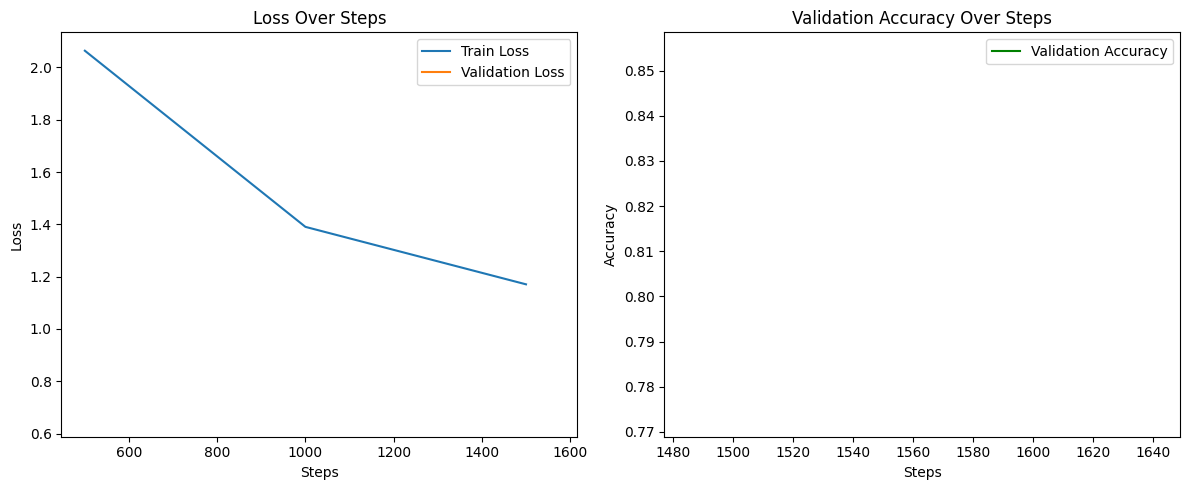

In [4]:
import matplotlib.pyplot as plt

# 학습 기록 가져오기
history = trainer.state.log_history

# 기록에서 손실(loss)과 정확도(accuracy) 데이터 추출
train_loss = [log['loss'] for log in history if 'loss' in log]
eval_loss = [log['eval_loss'] for log in history if 'eval_loss' in log]
eval_accuracy = [log['eval_accuracy'] for log in history if 'eval_accuracy' in log]
steps = [log['step'] for log in history if 'loss' in log]
eval_steps = [log['step'] for log in history if 'eval_loss' in log]

# 1. 손실 그래프 (Loss Curve)
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(steps, train_loss, label='Train Loss')
plt.plot(eval_steps, eval_loss, label='Validation Loss')
plt.title('Loss Over Steps')
plt.xlabel('Steps')
plt.ylabel('Loss')
plt.legend()

# 2. 정확도 그래프 (Accuracy Curve)
plt.subplot(1, 2, 2)
plt.plot(eval_steps, eval_accuracy, label='Validation Accuracy', color='green')
plt.title('Validation Accuracy Over Steps')
plt.xlabel('Steps')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()